In [ ]:
# Risk, Return, and Portfolio Analysis of Major US Technology Stocks (2016–2021)

## ACC102 Python Data Product - Track 2

This project uses WRDS data to analyse the performance of five major US technology stocks over the period from **2016 to 2021**:

- AAPL
- MSFT
- AMZN
- GOOGL
- TSLA

The project goes beyond basic price comparison by examining:

- daily returns
- annualised return
- annualised volatility
- Sharpe ratio
- Sortino ratio
- cumulative return
- maximum drawdown
- rolling volatility
- rolling correlation
- value at risk
- return distribution
- skewness and kurtosis
- winning and losing day patterns
- equal-weight portfolio performance

## Analysis Questions

1. Which stock delivered the strongest return during 2016–2021?
2. Which stock showed the highest level of risk during this period?
3. Which stock offered the best risk-adjusted performance?
4. How strongly were these stocks correlated over time?
5. Can an equal-weight portfolio improve diversification?

In [19]:
import os
import wrds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")
os.makedirs("outputs", exist_ok=True)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# 1. Connect to WRDS
This notebook connects to WRDS and extracts stock data from the CRSP daily stock file.

In [2]:
db = wrds.Connection()
print("Connected to WRDS successfully.")

WRDS recommends setting up a .pgpass file.
pgpass file created at C:\Users\YGspring\AppData\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
Connected to WRDS successfully.


In [ ]:
# 2. Check Stock Identifiers in CRSP
This step checks ticker information in CRSP for the selected stocks.

In [3]:
ticker_query = """
select distinct ticker, permno, comnam, namedt, nameendt
from crsp.dsenames
where ticker in ('AAPL', 'MSFT', 'AMZN', 'GOOGL', 'TSLA')
order by ticker, namedt
"""

ticker_info = db.raw_sql(ticker_query)
ticker_info.head(20)

,ticker,permno,comnam,namedt,nameendt
0,AAPL,14593,APPLE COMPUTER INC,1980-12-12,1982-10-31
1,AAPL,14593,APPLE COMPUTER INC,1982-11-01,2004-06-09
2,AAPL,14593,APPLE COMPUTER INC,2004-06-10,2007-01-10
3,AAPL,14593,APPLE INC,2007-01-11,2017-12-27
4,AAPL,14593,APPLE INC,2017-12-28,2024-12-31
5,AMZN,84788,AMAZON COM INC,1997-05-15,2004-06-09
6,AMZN,84788,AMAZON COM INC,2004-06-10,2014-01-14
7,AMZN,84788,AMAZON COM INC,2014-01-15,2020-03-18
8,AMZN,84788,AMAZON COM INC,2020-03-19,2024-07-31
9,AMZN,84788,AMAZON COM INC,2024-08-01,2024-12-31


In [ ]:
# 3. Download WRDS Data for 2016–2021
The following variables are extracted:

- date
- permno
- ticker
- company name
- price (`prc`)
- return (`ret`)
- volume (`vol`)

In [6]:
start_date = "2016-01-01"
end_date = "2021-12-31"

stock_query = f"""
select 
    a.date,
    a.permno,
    b.ticker,
    b.comnam,
    abs(a.prc) as prc,
    a.ret,
    a.vol
from crsp.dsf as a
join crsp.dsenames as b
    on a.permno = b.permno
    and a.date between b.namedt and b.nameendt
where b.ticker in ('AAPL', 'MSFT', 'AMZN', 'GOOGL', 'TSLA')
  and a.date between '{start_date}' and '{end_date}'
order by a.date, b.ticker
"""

raw_df = db.raw_sql(stock_query)

print("Downloaded data shape:", raw_df.shape)
raw_df.head()

Downloaded data shape: (7555, 7)


,date,permno,ticker,comnam,prc,ret,vol
0,2016-01-04,14593,AAPL,APPLE INC,105.35,0.000855,69383612.0
1,2016-01-04,84788,AMZN,AMAZON COM INC,636.98999,-0.057554,9314519.0
2,2016-01-04,90319,GOOGL,ALPHABET INC,759.44,-0.023869,3369068.0
3,2016-01-04,10107,MSFT,MICROSOFT CORP,54.8,-0.012257,53777963.0
4,2016-01-04,93436,TSLA,TESLA MOTORS INC,223.41,-0.069164,6827299.0


In [7]:
print("Date range in raw data:")
print(raw_df["date"].min(), "to", raw_df["date"].max())
print(raw_df.dtypes)

Date range in raw data:
2016-01-04 to 2021-12-31
date      string[python]
permno             Int64
ticker    string[python]
comnam    string[python]
prc              Float64
ret              Float64
vol              Float64
dtype: object


In [ ]:
# 4. Clean the WRDS Data
This step:

- converts dates
- converts numeric columns
- removes missing values
- sorts the data

In [8]:
df = raw_df.copy()

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["prc"] = pd.to_numeric(df["prc"], errors="coerce")
df["ret"] = pd.to_numeric(df["ret"], errors="coerce")
df["vol"] = pd.to_numeric(df["vol"], errors="coerce")

df = df.dropna(subset=["date", "ticker", "prc", "ret"])
df = df.sort_values(["ticker", "date"])

print("Cleaned data shape:", df.shape)
print("Date range after cleaning:", df["date"].min(), "to", df["date"].max())
df.head()

Cleaned data shape: (7555, 7)
Date range after cleaning: 2016-01-04 00:00:00 to 2021-12-31 00:00:00


,date,permno,ticker,comnam,prc,ret,vol
0,2016-01-04,14593,AAPL,APPLE INC,105.35,0.000855,69383612.0
5,2016-01-05,14593,AAPL,APPLE INC,102.71,-0.025059,55791042.0
10,2016-01-06,14593,AAPL,APPLE INC,100.7,-0.01957,68487388.0
15,2016-01-07,14593,AAPL,APPLE INC,96.45,-0.042205,81466204.0
20,2016-01-08,14593,AAPL,APPLE INC,96.96,0.005288,70798746.0


In [ ]:
# 5. Create Price and Return Tables
The cleaned data are reshaped into wide-format tables for prices and returns.

In [9]:
price_df = df.pivot(index="date", columns="ticker", values="prc").sort_index()
returns_df = df.pivot(index="date", columns="ticker", values="ret").sort_index()

price_df = price_df.dropna()
returns_df = returns_df.loc[price_df.index].dropna()

print("Price table shape:", price_df.shape)
print("Return table shape:", returns_df.shape)
print("Price table date range:", price_df.index.min(), "to", price_df.index.max())
print("Return table date range:", returns_df.index.min(), "to", returns_df.index.max())

price_df.head()

Price table shape: (1511, 5)
Return table shape: (1511, 5)
Price table date range: 2016-01-04 00:00:00 to 2021-12-31 00:00:00
Return table date range: 2016-01-04 00:00:00 to 2021-12-31 00:00:00


ticker,AAPL,AMZN,GOOGL,MSFT,TSLA
date,,,,,
2016-01-04,105.35,636.98999,759.44,54.8,223.41
2016-01-05,102.71,633.78998,761.53003,55.05,223.42999
2016-01-06,100.7,632.65002,759.33002,54.05,219.03999
2016-01-07,96.45,607.94,741.0,52.17,215.64999
2016-01-08,96.96,607.04999,730.90997,52.33,211.0


In [ ]:
# 6. Save Cleaned Data

In [10]:
price_df.to_csv("outputs/wrds_price_data_2016_2021.csv")
returns_df.to_csv("outputs/wrds_return_data_2016_2021.csv")

print("Cleaned data saved.")

Cleaned data saved.


In [ ]:
# 7. Descriptive Statistics

In [11]:
price_stats = price_df.describe()
return_stats = returns_df.describe()

print(price_stats)
print(return_stats)

price_stats.to_csv("outputs/price_statistics.csv")
return_stats.to_csv("outputs/return_statistics.csv")

ticker        AAPL         AMZN        GOOGL       MSFT        TSLA
count       1511.0       1511.0       1511.0     1511.0      1511.0
mean    175.623878  1855.162445  1330.451152  138.04224  447.351201
std       71.08609   954.706027   588.203271   78.48241  303.952169
min          90.34    482.07001    681.14001      48.43      143.67
25%          125.5   967.994995      947.595      71.18  251.270005
50%         156.83      1749.62   1145.17004     110.26   328.23999
75%        200.645     2921.125  1479.315005    201.965     605.125
max         506.09   3731.40991   2996.77002  343.10999     2238.75
ticker      AAPL      AMZN     GOOGL      MSFT      TSLA
count     1511.0    1511.0    1511.0    1511.0    1511.0
mean     0.00149  0.001228  0.001005  0.001401  0.002697
std     0.018503   0.01856  0.016396  0.016845  0.036115
min    -0.128647 -0.079221 -0.116342  -0.14739 -0.210628
25%    -0.006242 -0.007286 -0.005791 -0.005671 -0.014497
50%     0.001134  0.001409  0.001275  0.001101

In [ ]:
# 8. Price Trends

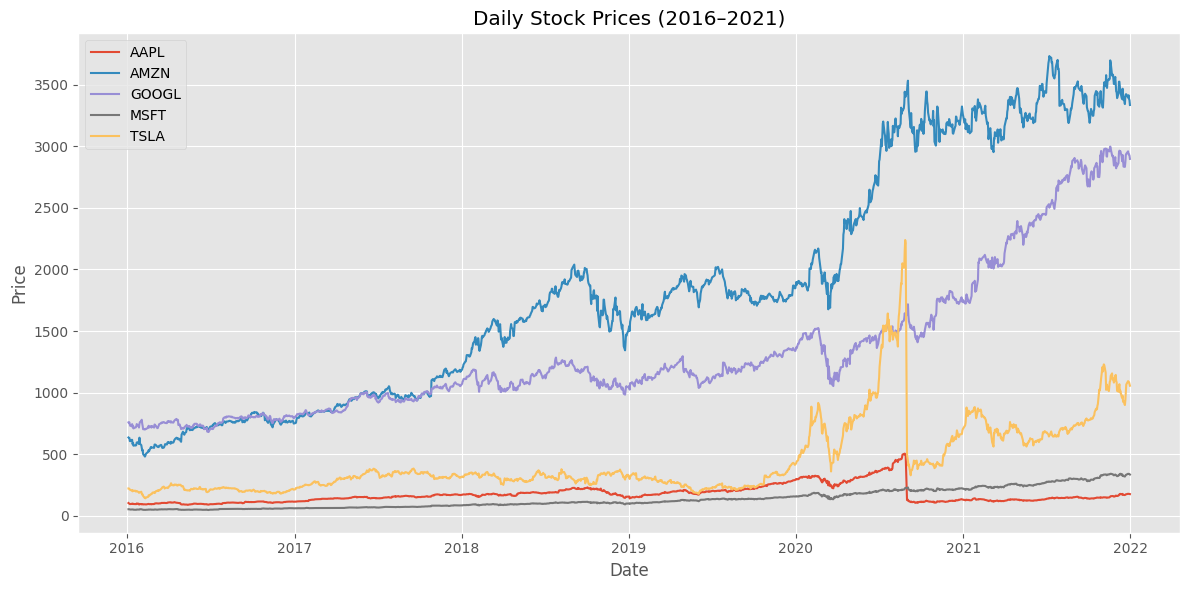

In [12]:
plt.figure(figsize=(12, 6))
for col in price_df.columns:
    plt.plot(price_df.index, price_df[col], label=col)

plt.title("Daily Stock Prices (2016–2021)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/price_trends.png", dpi=300)
plt.show()

In [ ]:
# 9. Risk and Return Metrics

In [13]:
mean_daily_return = returns_df.mean()
daily_volatility = returns_df.std()

annual_return = mean_daily_return * 252
annual_volatility = daily_volatility * np.sqrt(252)

risk_free_rate = 0.02
sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility

summary_df = pd.DataFrame({
    "Mean Daily Return": mean_daily_return,
    "Daily Volatility": daily_volatility,
    "Annual Return": annual_return,
    "Annual Volatility": annual_volatility,
    "Sharpe Ratio": sharpe_ratio
})

print(summary_df)
summary_df.to_csv("outputs/risk_return_summary.csv")

        Mean Daily Return  Daily Volatility  Annual Return  Annual Volatility  \
ticker                                                                          
AAPL              0.00149          0.018503       0.375581           0.293727   
AMZN             0.001228           0.01856       0.309562           0.294634   
GOOGL            0.001005          0.016396       0.253273           0.260277   
MSFT             0.001401          0.016845       0.353136           0.267401   
TSLA             0.002697          0.036115       0.679754           0.573313   

        Sharpe Ratio  
ticker                
AAPL        1.210583  
AMZN        0.982787  
GOOGL       0.896249  
MSFT         1.24583  
TSLA        1.150774  


In [ ]:
# 10. Cumulative Return

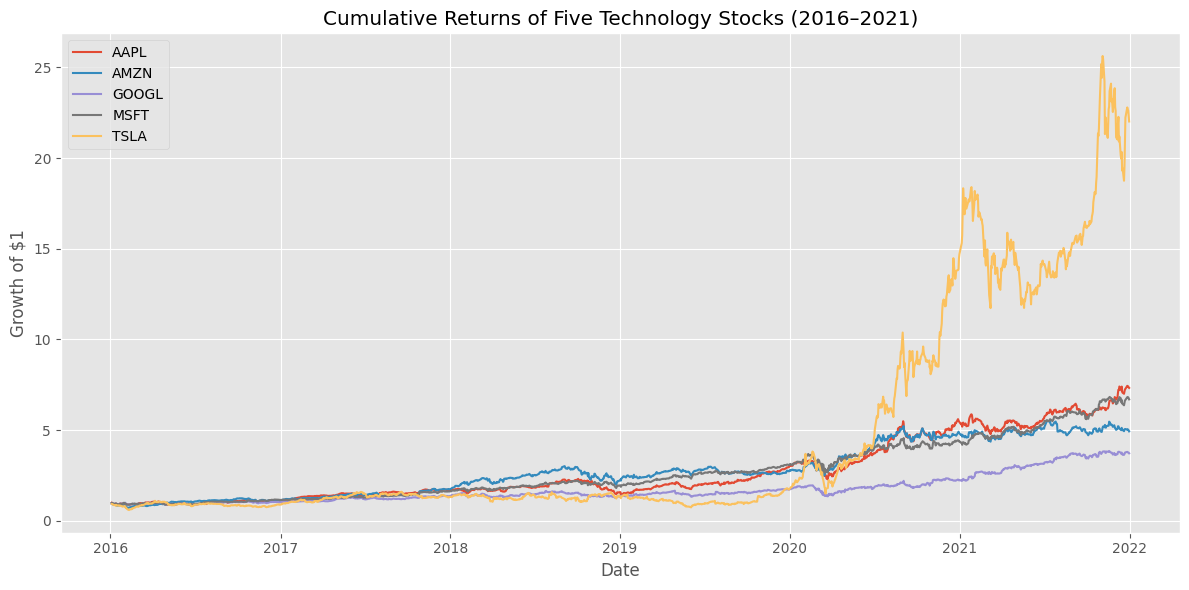

In [14]:
cumulative_returns = (1 + returns_df).cumprod()

plt.figure(figsize=(12, 6))
for col in cumulative_returns.columns:
    plt.plot(cumulative_returns.index, cumulative_returns[col], label=col)

plt.title("Cumulative Returns of Five Technology Stocks (2016–2021)")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/cumulative_returns.png", dpi=300)
plt.show()

In [ ]:
# 11. Maximum Drawdown

In [15]:
rolling_max = cumulative_returns.cummax()
drawdown = cumulative_returns / rolling_max - 1
max_drawdown = drawdown.min()

print(max_drawdown)
max_drawdown.to_csv("outputs/max_drawdown.csv")

ticker
AAPL    -0.385152
AMZN    -0.341035
GOOGL   -0.308708
MSFT    -0.280399
TSLA    -0.606266
dtype: Float64


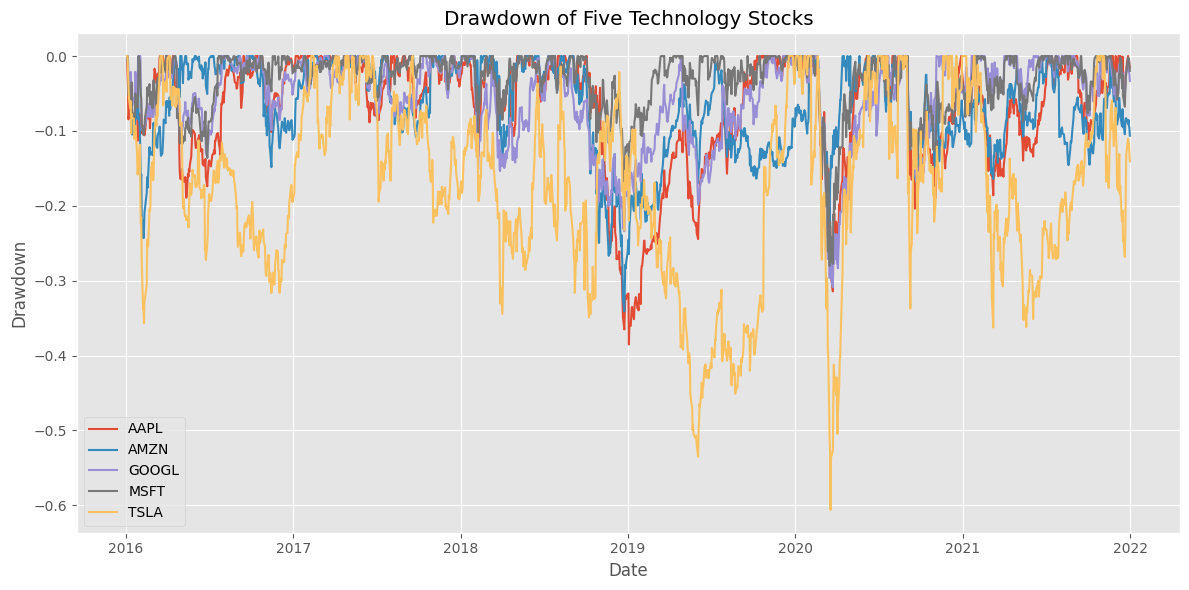

In [16]:
plt.figure(figsize=(12, 6))
for col in drawdown.columns:
    plt.plot(drawdown.index, drawdown[col], label=col)

plt.title("Drawdown of Five Technology Stocks")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/drawdown_plot.png", dpi=300)
plt.show()

In [ ]:
# 12. Rolling Volatility
A 30-day rolling standard deviation is used to show how short-term risk changes over time.

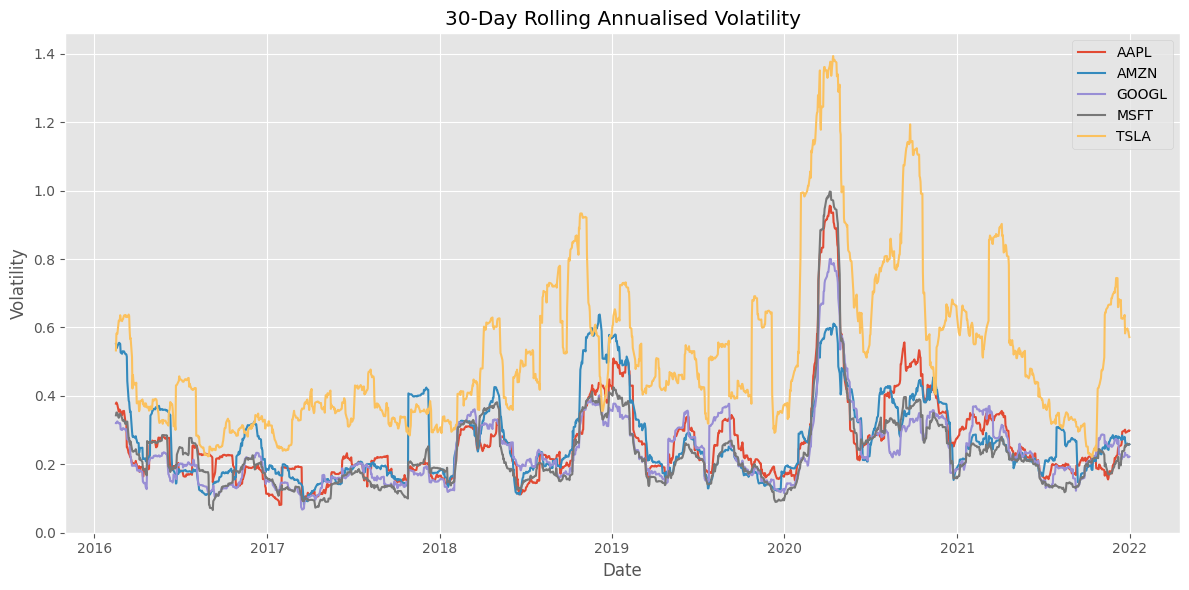

In [17]:
rolling_volatility = returns_df.rolling(window=30).std() * np.sqrt(252)

plt.figure(figsize=(12, 6))
for col in rolling_volatility.columns:
    plt.plot(rolling_volatility.index, rolling_volatility[col], label=col)

plt.title("30-Day Rolling Annualised Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/rolling_volatility.png", dpi=300)
plt.show()

In [18]:
correlation_matrix = returns_df.corr()
print(correlation_matrix)

correlation_matrix.to_csv("outputs/correlation_matrix.csv")

ticker      AAPL      AMZN     GOOGL      MSFT      TSLA
ticker                                                  
AAPL    1.000000  0.593924  0.640137  0.709856  0.392983
AMZN    0.593924  1.000000  0.652104  0.672477  0.361272
GOOGL   0.640137  0.652104  1.000000  0.773363  0.353652
MSFT    0.709856  0.672477  0.773363  1.000000  0.407112
TSLA    0.392983  0.361272  0.353652  0.407112  1.000000


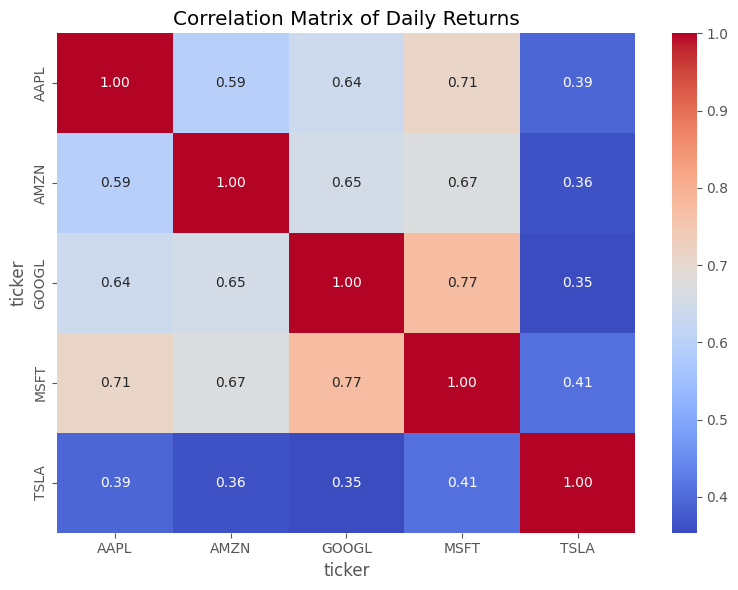

In [20]:
try:
    import seaborn as sns
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Matrix of Daily Returns")
    plt.tight_layout()
    plt.savefig("outputs/correlation_heatmap.png", dpi=300)
    plt.show()
except ImportError:
    print("Seaborn not installed; skipping heatmap.")

In [ ]:
# 14. Rolling Correlation Example
The rolling correlation between AAPL and MSFT is used as an example to show how relationships between stocks change over time.

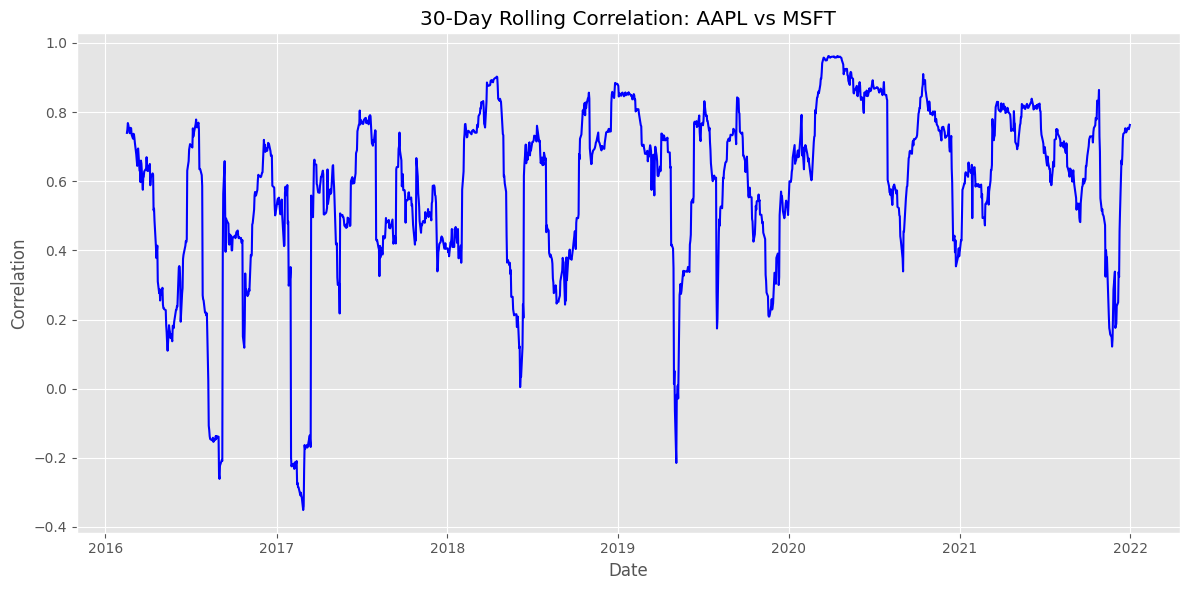

In [21]:
rolling_corr_aapl_msft = returns_df["AAPL"].rolling(window=30).corr(returns_df["MSFT"])

plt.figure(figsize=(12, 6))
plt.plot(rolling_corr_aapl_msft.index, rolling_corr_aapl_msft, color="blue")
plt.title("30-Day Rolling Correlation: AAPL vs MSFT")
plt.xlabel("Date")
plt.ylabel("Correlation")
plt.tight_layout()
plt.savefig("outputs/rolling_corr_aapl_msft.png", dpi=300)
plt.show()

In [ ]:
# 15. Monthly Return Analysis
Daily prices are resampled into monthly prices to identify medium-term performance patterns.

In [22]:
monthly_prices = price_df.resample("M").last()
monthly_returns = monthly_prices.pct_change().dropna()

print(monthly_returns.head())
monthly_returns.to_csv("outputs/monthly_returns.csv")

ticker          AAPL      AMZN     GOOGL      MSFT      TSLA
date                                                        
2016-02-29 -0.006678 -0.058739 -0.057963  -0.07642  0.003818
2016-03-31  0.127211  0.074423   0.06369  0.085495  0.197155
2016-04-30 -0.139921  0.111094  -0.07212 -0.097049   0.04783
2016-05-31  0.065287  0.095817  0.057877  0.062763 -0.072811
2016-06-30  -0.04266  -0.00992 -0.060519 -0.034528 -0.049053


C:\Users\YGspring\AppData\Local\Temp\ipykernel_34568\752861283.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_prices = price_df.resample("M").last()


In [ ]:
# 16. Distribution of Daily Returns
A histogram is used to examine the distribution of daily returns for each stock.

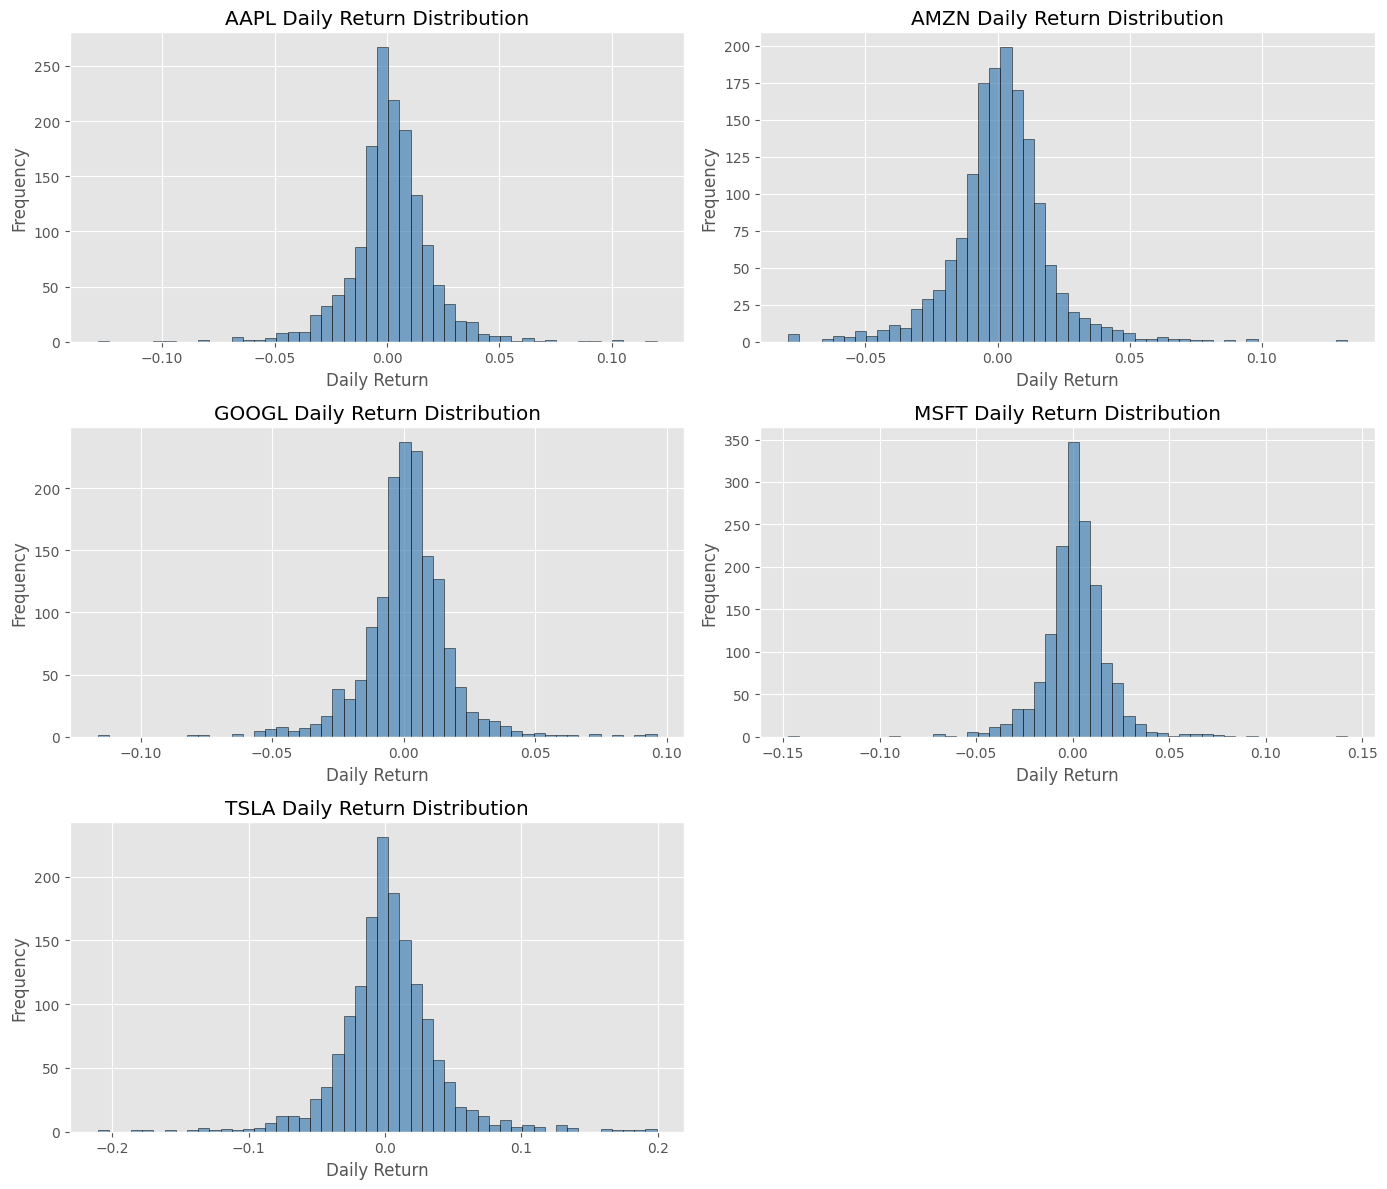

In [24]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

stocks = returns_df.columns.tolist()

for i, stock in enumerate(stocks):
    axes[i].hist(returns_df[stock], bins=50, alpha=0.7, color="steelblue", edgecolor="black")
    axes[i].set_title(f"{stock} Daily Return Distribution")
    axes[i].set_xlabel("Daily Return")
    axes[i].set_ylabel("Frequency")

if len(stocks) < len(axes):
    for j in range(len(stocks), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("outputs/daily_return_histograms.png", dpi=300)
plt.show()

In [ ]:
# 17. Boxplot of Daily Returns
Boxplots allow a direct comparison of median return, dispersion, and outliers.

C:\Users\YGspring\AppData\Local\Temp\ipykernel_34568\3448729489.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([returns_df[col] for col in returns_df.columns], labels=returns_df.columns)


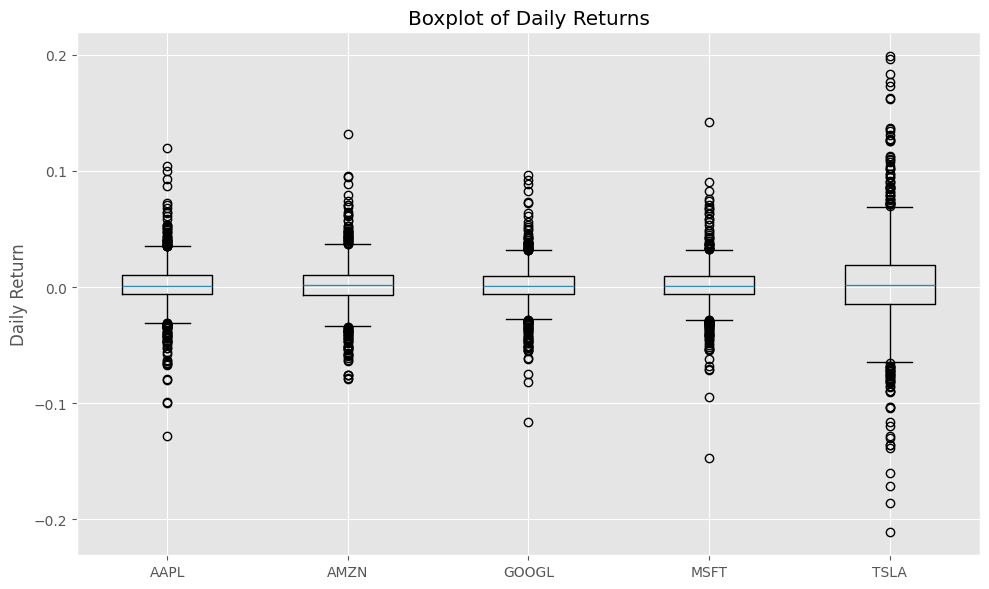

In [26]:
plt.figure(figsize=(10, 6))
plt.boxplot([returns_df[col] for col in returns_df.columns], labels=returns_df.columns)
plt.title("Boxplot of Daily Returns")
plt.ylabel("Daily Return")
plt.tight_layout()
plt.savefig("outputs/daily_return_boxplot.png", dpi=300)
plt.show()

In [ ]:
# 18. Rolling Sharpe Ratio
A 60-day rolling Sharpe ratio is used to show how risk-adjusted performance changes over time.

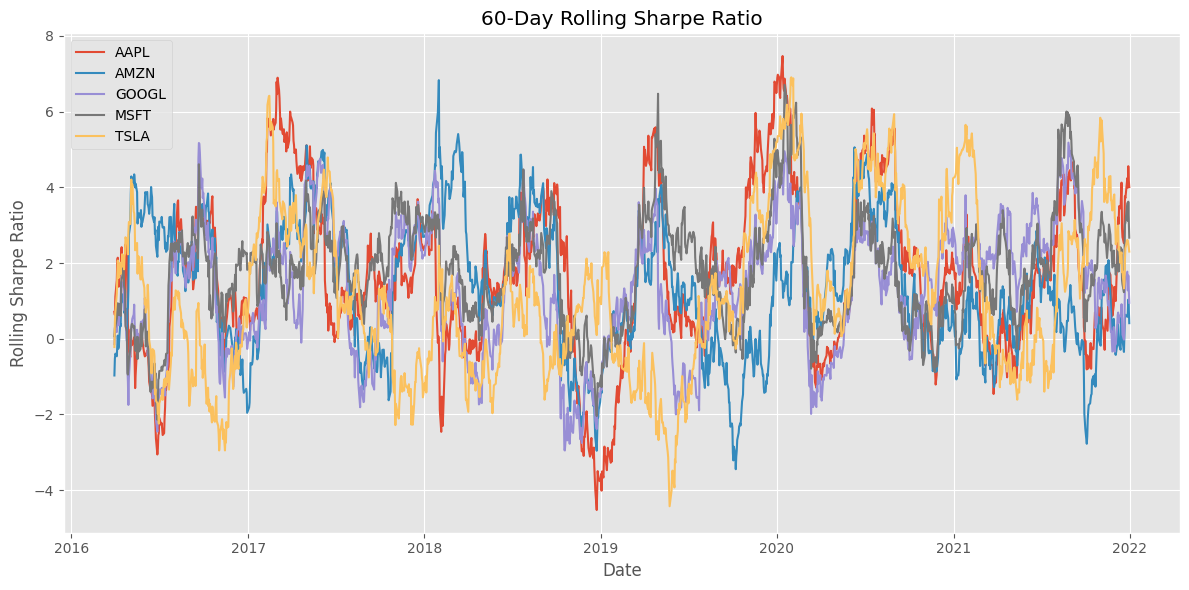

In [25]:
rolling_mean_60 = returns_df.rolling(window=60).mean() * 252
rolling_std_60 = returns_df.rolling(window=60).std() * np.sqrt(252)
rolling_sharpe = (rolling_mean_60 - risk_free_rate) / rolling_std_60

plt.figure(figsize=(12, 6))
for col in rolling_sharpe.columns:
    plt.plot(rolling_sharpe.index, rolling_sharpe[col], label=col)

plt.title("60-Day Rolling Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/rolling_sharpe_ratio.png", dpi=300)
plt.show()

In [ ]:
# 19. Historical Value at Risk (VaR)
Historical VaR estimates potential downside loss based on past returns.

In [27]:
var_95 = returns_df.quantile(0.05)

var_summary = pd.DataFrame({
    "Historical VaR (95%)": var_95
})

print(var_summary)
var_summary.to_csv("outputs/var_95_summary.csv")

        Historical VaR (95%)
ticker                      
AAPL               -0.026667
AMZN               -0.028399
GOOGL              -0.025209
MSFT               -0.024931
TSLA               -0.049666


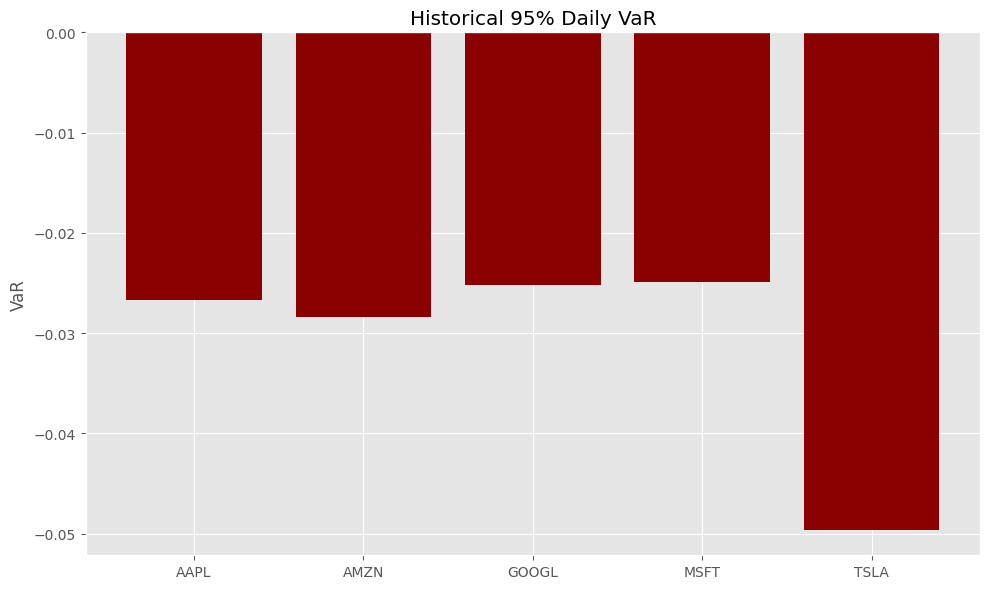

In [28]:
plt.figure(figsize=(10, 6))
plt.bar(var_summary.index, var_summary["Historical VaR (95%)"], color="darkred")
plt.title("Historical 95% Daily VaR")
plt.ylabel("VaR")
plt.tight_layout()
plt.savefig("outputs/var_95_bar.png", dpi=300)
plt.show()

In [ ]:
# 20. Equal-Weight Portfolio Analysis
A simple equal-weight portfolio is created by assigning 20% to each stock.

In [29]:
weights = np.array([0.2, 0.2, 0.2, 0.2, 0.2])

portfolio_returns = returns_df.dot(weights)
portfolio_cumulative = (1 + portfolio_returns).cumprod()

portfolio_summary = {
    "Mean Daily Return": portfolio_returns.mean(),
    "Daily Volatility": portfolio_returns.std(),
    "Annual Return": portfolio_returns.mean() * 252,
    "Annual Volatility": portfolio_returns.std() * np.sqrt(252),
}

portfolio_summary["Sharpe Ratio"] = (
    (portfolio_summary["Annual Return"] - risk_free_rate) /
    portfolio_summary["Annual Volatility"]
)

portfolio_summary_df = pd.DataFrame(portfolio_summary, index=["Equal-Weight Portfolio"])
print(portfolio_summary_df)

portfolio_summary_df.to_csv("outputs/portfolio_summary.csv")

                        Mean Daily Return  Daily Volatility  Annual Return  \
Equal-Weight Portfolio           0.001565          0.016674       0.394261   

                        Annual Volatility  Sharpe Ratio  
Equal-Weight Portfolio           0.264696      1.413926  


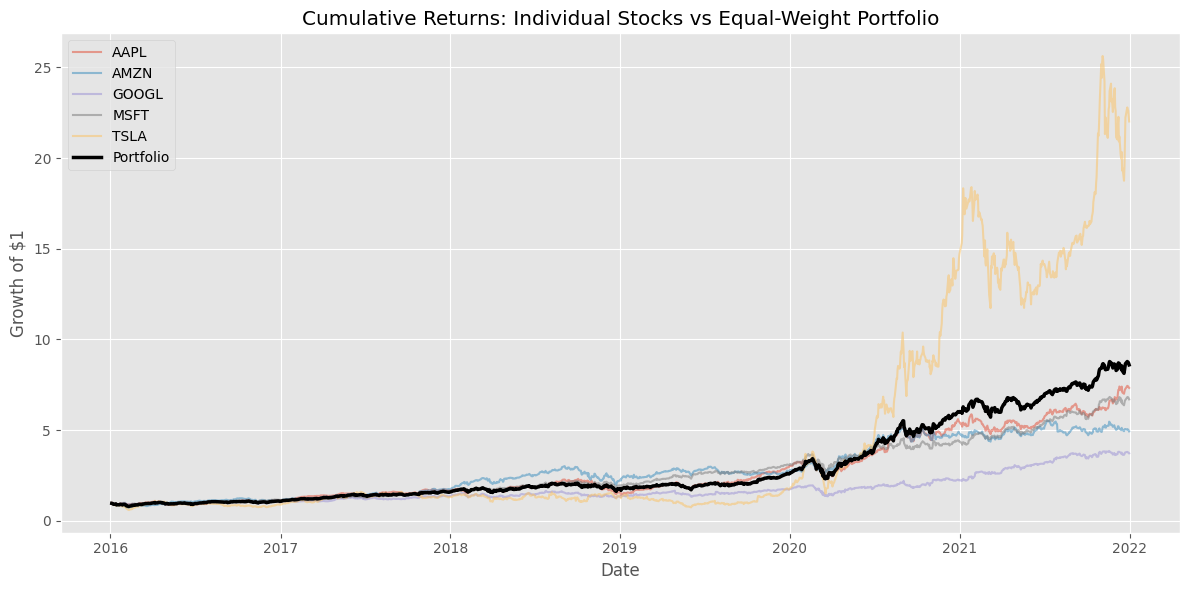

In [30]:
plt.figure(figsize=(12, 6))

for col in cumulative_returns.columns:
    plt.plot(cumulative_returns.index, cumulative_returns[col], alpha=0.5, label=col)

plt.plot(portfolio_cumulative.index, portfolio_cumulative, color="black", linewidth=2.5, label="Portfolio")

plt.title("Cumulative Returns: Individual Stocks vs Equal-Weight Portfolio")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/portfolio_vs_stocks.png", dpi=300)
plt.show()

In [ ]:
# 21. Portfolio Value at Risk
The historical VaR of the equal-weight portfolio is calculated to assess whether diversification reduces downside risk.

In [31]:
portfolio_var_95 = portfolio_returns.quantile(0.05)
print("Equal-weight portfolio historical 95% VaR:", portfolio_var_95)

Equal-weight portfolio historical 95% VaR: -0.026691900000000005


In [ ]:
# 22. Beta Analysis Relative to the Equal-Weight Portfolio
Beta measures how sensitive each stock is to movements in the benchmark portfolio.

In [35]:
beta_results = {}

var_portfolio = portfolio_returns.var()

if var_portfolio == 0:
    print("Portfolio variance is zero; beta cannot be calculated.")
else:
    for stock in returns_df.columns:
        cov = returns_df[stock].cov(portfolio_returns)
        beta = cov / var_portfolio
        beta_results[stock] = beta

    beta_df = pd.DataFrame.from_dict(beta_results, orient="index", columns=["Beta vs Portfolio"])
    print(beta_df)
    beta_df.to_csv("outputs/beta_vs_portfolio.csv")
    print("Beta results saved to outputs/beta_vs_portfolio.csv")

       Beta vs Portfolio
AAPL            0.880751
AMZN            0.862701
GOOGL           0.780105
MSFT            0.846297
TSLA            1.630147
Beta results saved to outputs/beta_vs_portfolio.csv


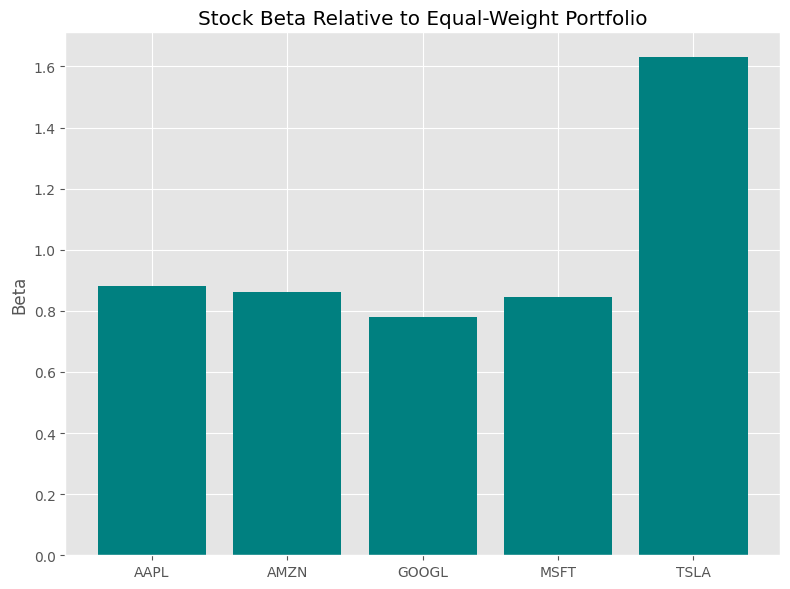

In [36]:
plt.figure(figsize=(8, 6))
plt.bar(beta_df.index, beta_df["Beta vs Portfolio"], color="teal")
plt.title("Stock Beta Relative to Equal-Weight Portfolio")
plt.ylabel("Beta")
plt.tight_layout()
plt.savefig("outputs/beta_vs_portfolio.png", dpi=300)
plt.show()

In [ ]:
# 23. Downside Risk and Sortino Ratio
The Sortino ratio focuses only on downside risk rather than total volatility.

In [37]:
downside_returns = returns_df.copy()

for col in downside_returns.columns:
    downside_returns[col] = downside_returns[col].where(downside_returns[col] < 0, 0)

downside_deviation = np.sqrt((downside_returns**2).mean()) * np.sqrt(252)
sortino_ratio = (annual_return - risk_free_rate) / downside_deviation

sortino_summary = pd.DataFrame({
    "Annual Return": annual_return,
    "Annual Volatility": annual_volatility,
    "Downside Deviation": downside_deviation,
    "Sharpe Ratio": sharpe_ratio,
    "Sortino Ratio": sortino_ratio
})

print(sortino_summary)
sortino_summary.to_csv("outputs/sortino_summary.csv")

        Annual Return  Annual Volatility  Downside Deviation  Sharpe Ratio  \
ticker                                                                       
AAPL         0.375581           0.293727            0.198728      1.210583   
AMZN         0.309562           0.294634            0.197503      0.982787   
GOOGL        0.253273           0.260277            0.181099      0.896249   
MSFT         0.353136           0.267401            0.179744       1.24583   
TSLA         0.679754           0.573313            0.372371      1.150774   

        Sortino Ratio  
ticker                 
AAPL         1.789287  
AMZN         1.466118  
GOOGL        1.288093  
MSFT         1.853392  
TSLA         1.771762  


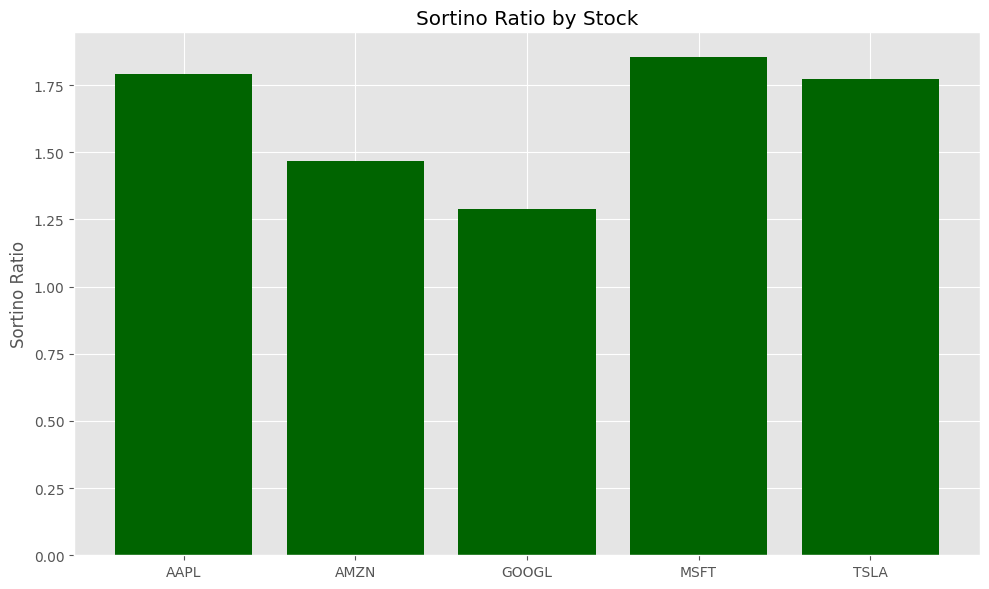

In [38]:
plt.figure(figsize=(10, 6))
plt.bar(sortino_summary.index, sortino_summary["Sortino Ratio"], color="darkgreen")
plt.title("Sortino Ratio by Stock")
plt.ylabel("Sortino Ratio")
plt.tight_layout()
plt.savefig("outputs/sortino_ratio_bar.png", dpi=300)
plt.show()

In [ ]:
# 24. Skewness and Kurtosis
Financial returns are often not normally distributed, so skewness and kurtosis are useful for understanding tail behaviour.

In [39]:
distribution_stats = pd.DataFrame({
    "Mean": returns_df.mean(),
    "Std Dev": returns_df.std(),
    "Skewness": returns_df.skew(),
    "Kurtosis": returns_df.kurtosis(),
    "Min": returns_df.min(),
    "Max": returns_df.max()
})

print(distribution_stats)
distribution_stats.to_csv("outputs/distribution_statistics.csv")

            Mean   Std Dev  Skewness   Kurtosis       Min       Max
ticker                                                             
AAPL     0.00149  0.018503 -0.097561    6.75677 -0.128647  0.119808
AMZN    0.001228   0.01856  0.243558    4.89976 -0.079221  0.132164
GOOGL   0.001005  0.016396  -0.15771   6.027351 -0.116342  0.096202
MSFT    0.001401  0.016845 -0.028242  10.553395  -0.14739  0.142169
TSLA    0.002697  0.036115  0.266003   5.501638 -0.210628  0.198949


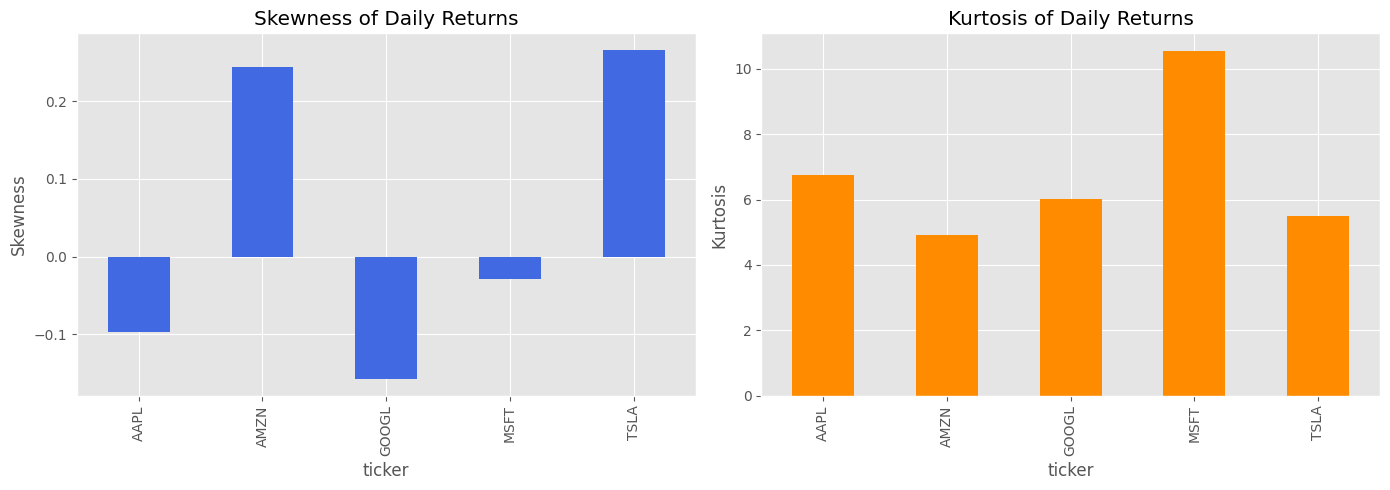

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

distribution_stats["Skewness"].plot(kind="bar", ax=axes[0], color="royalblue")
axes[0].set_title("Skewness of Daily Returns")
axes[0].set_ylabel("Skewness")

distribution_stats["Kurtosis"].plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Kurtosis of Daily Returns")
axes[1].set_ylabel("Kurtosis")

plt.tight_layout()
plt.savefig("outputs/skewness_kurtosis_bar.png", dpi=300)
plt.show()

In [ ]:
# 25. Winning and Losing Days Analysis
This section examines how often each stock records positive and negative daily returns.

In [41]:
winning_days = (returns_df > 0).sum()
losing_days = (returns_df < 0).sum()
zero_days = (returns_df == 0).sum()
total_days = returns_df.count()

win_loss_summary = pd.DataFrame({
    "Winning Days": winning_days,
    "Losing Days": losing_days,
    "Zero Return Days": zero_days,
    "Total Days": total_days
})

win_loss_summary["Winning Ratio"] = win_loss_summary["Winning Days"] / win_loss_summary["Total Days"]
win_loss_summary["Losing Ratio"] = win_loss_summary["Losing Days"] / win_loss_summary["Total Days"]

print(win_loss_summary)
win_loss_summary.to_csv("outputs/win_loss_summary.csv")

        Winning Days  Losing Days  Zero Return Days  Total Days  \
ticker                                                            
AAPL             818          690                 3        1511   
AMZN             830          680                 1        1511   
GOOGL            820          690                 1        1511   
MSFT             831          667                13        1511   
TSLA             791          719                 1        1511   

        Winning Ratio  Losing Ratio  
ticker                               
AAPL         0.541363      0.456651  
AMZN         0.549305      0.450033  
GOOGL        0.542687      0.456651  
MSFT         0.549967       0.44143  
TSLA         0.523494      0.475844  


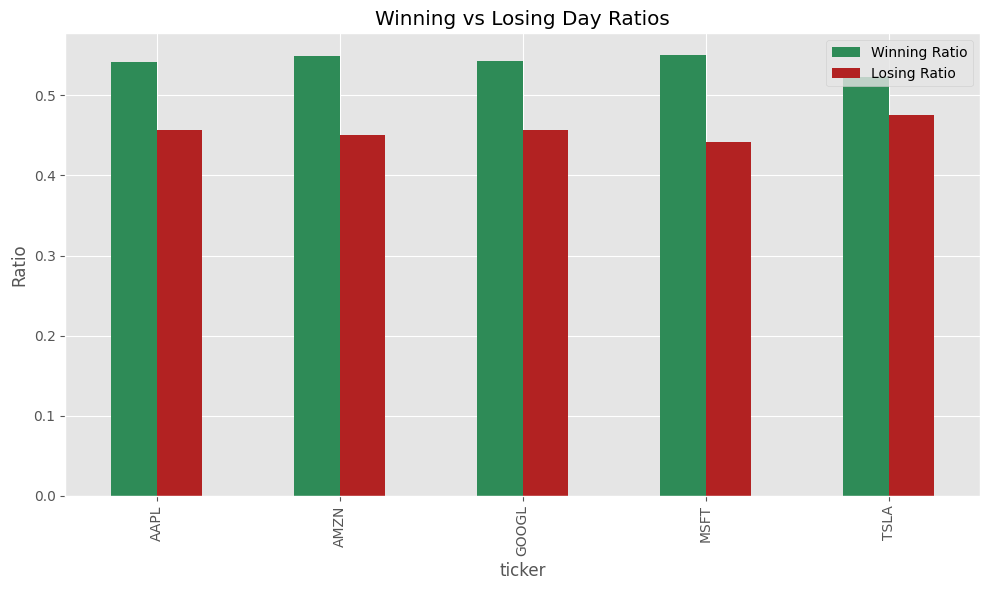

In [42]:
win_loss_summary[["Winning Ratio", "Losing Ratio"]].plot(
    kind="bar",
    figsize=(10, 6),
    color=["seagreen", "firebrick"]
)

plt.title("Winning vs Losing Day Ratios")
plt.ylabel("Ratio")
plt.tight_layout()
plt.savefig("outputs/win_loss_ratios.png", dpi=300)
plt.show()

In [ ]:
# 26. Extreme Daily Movement Analysis
This section identifies days with very strong gains and very large losses.

In [43]:
extreme_gain_days = (returns_df > 0.02).sum()
extreme_loss_days = (returns_df < -0.02).sum()

extreme_summary = pd.DataFrame({
    "Extreme Gain Days (>2%)": extreme_gain_days,
    "Extreme Loss Days (<-2%)": extreme_loss_days
})

print(extreme_summary)
extreme_summary.to_csv("outputs/extreme_days_summary.csv")

        Extreme Gain Days (>2%)  Extreme Loss Days (<-2%)
ticker                                                   
AAPL                        156                       135
AMZN                        147                       140
GOOGL                       107                       123
MSFT                        134                       108
TSLA                        358                       303


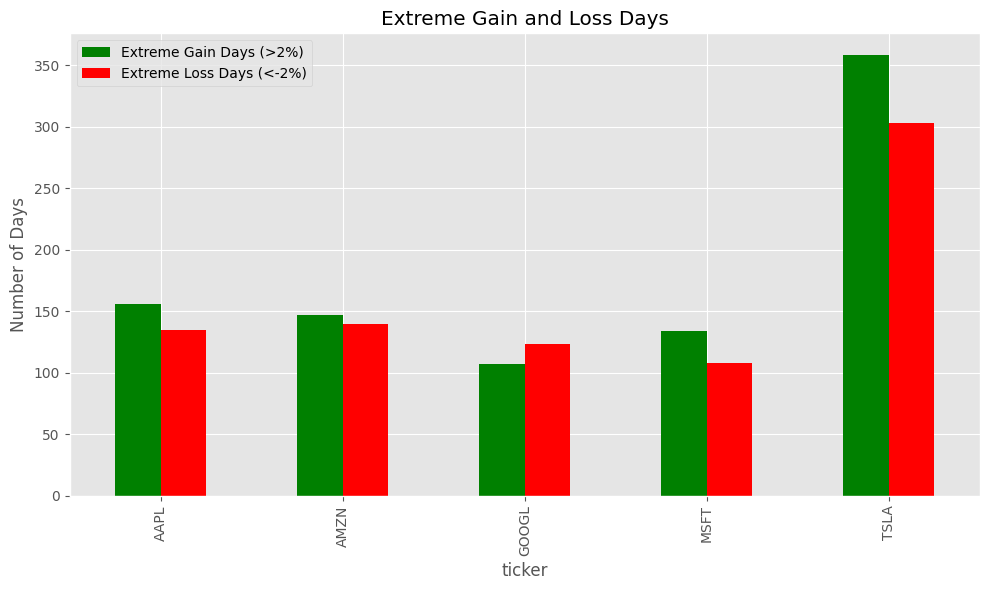

In [44]:
extreme_summary.plot(kind="bar", figsize=(10, 6), color=["green", "red"])
plt.title("Extreme Gain and Loss Days")
plt.ylabel("Number of Days")
plt.tight_layout()
plt.savefig("outputs/extreme_days_bar.png", dpi=300)
plt.show()

In [ ]:
# 27. Consistency Score
A simple consistency score is created using the winning ratio.

In [45]:
consistency_score = win_loss_summary[["Winning Ratio"]].copy()
consistency_score = consistency_score.sort_values("Winning Ratio", ascending=False)

print(consistency_score)
consistency_score.to_csv("outputs/consistency_score.csv")

        Winning Ratio
ticker               
MSFT         0.549967
AMZN         0.549305
GOOGL        0.542687
AAPL         0.541363
TSLA         0.523494


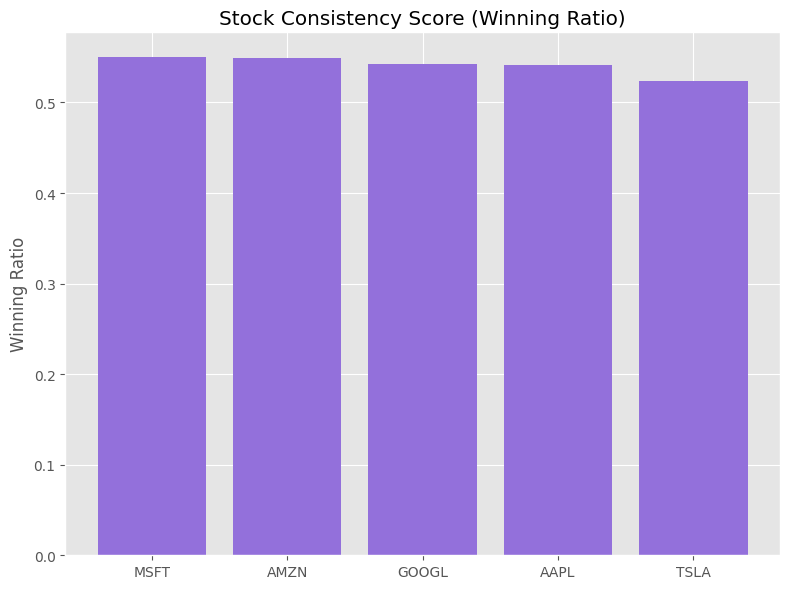

In [46]:
plt.figure(figsize=(8, 6))
plt.bar(consistency_score.index, consistency_score["Winning Ratio"], color="mediumpurple")
plt.title("Stock Consistency Score (Winning Ratio)")
plt.ylabel("Winning Ratio")
plt.tight_layout()
plt.savefig("outputs/consistency_score_bar.png", dpi=300)
plt.show()

In [ ]:
# 28. Extended Performance Summary
This table combines return, volatility, downside risk, distribution shape, and consistency metrics.

In [47]:
extended_summary = pd.DataFrame({
    "Annual Return": annual_return,
    "Annual Volatility": annual_volatility,
    "Sharpe Ratio": sharpe_ratio,
    "Sortino Ratio": sortino_ratio,
    "Max Drawdown": max_drawdown,
    "Skewness": returns_df.skew(),
    "Kurtosis": returns_df.kurtosis(),
    "Winning Ratio": win_loss_summary["Winning Ratio"]
})

print(extended_summary)
extended_summary.to_csv("outputs/extended_summary.csv")

        Annual Return  Annual Volatility  Sharpe Ratio  Sortino Ratio  \
ticker                                                                  
AAPL         0.375581           0.293727      1.210583       1.789287   
AMZN         0.309562           0.294634      0.982787       1.466118   
GOOGL        0.253273           0.260277      0.896249       1.288093   
MSFT         0.353136           0.267401       1.24583       1.853392   
TSLA         0.679754           0.573313      1.150774       1.771762   

        Max Drawdown  Skewness   Kurtosis  Winning Ratio  
ticker                                                    
AAPL       -0.385152 -0.097561    6.75677       0.541363  
AMZN       -0.341035  0.243558    4.89976       0.549305  
GOOGL      -0.308708  -0.15771   6.027351       0.542687  
MSFT       -0.280399 -0.028242  10.553395       0.549967  
TSLA       -0.606266  0.266003   5.501638       0.523494  


In [ ]:
# 29. Performance Ranking
A ranking table is created for annual return, volatility, Sharpe ratio, and drawdown.

In [48]:
ranking_df = summary_df.copy()
ranking_df["Max Drawdown"] = max_drawdown

ranking_df["Return Rank"] = ranking_df["Annual Return"].rank(ascending=False)
ranking_df["Volatility Rank"] = ranking_df["Annual Volatility"].rank(ascending=True)
ranking_df["Sharpe Rank"] = ranking_df["Sharpe Ratio"].rank(ascending=False)
ranking_df["Drawdown Rank"] = ranking_df["Max Drawdown"].rank(ascending=False)

print(ranking_df.sort_values("Sharpe Rank"))
ranking_df.to_csv("outputs/performance_ranking.csv")

        Mean Daily Return  Daily Volatility  Annual Return  Annual Volatility  \
ticker                                                                          
MSFT             0.001401          0.016845       0.353136           0.267401   
AAPL              0.00149          0.018503       0.375581           0.293727   
TSLA             0.002697          0.036115       0.679754           0.573313   
AMZN             0.001228           0.01856       0.309562           0.294634   
GOOGL            0.001005          0.016396       0.253273           0.260277   

        Sharpe Ratio  Max Drawdown  Return Rank  Volatility Rank  Sharpe Rank  \
ticker                                                                          
MSFT         1.24583     -0.280399          3.0              2.0          1.0   
AAPL        1.210583     -0.385152          2.0              3.0          2.0   
TSLA        1.150774     -0.606266          1.0              5.0          3.0   
AMZN        0.982787     -0

In [ ]:
# 30. Multi-Metric Comparison Radar Chart
A radar chart is used to compare stocks across multiple performance dimensions.

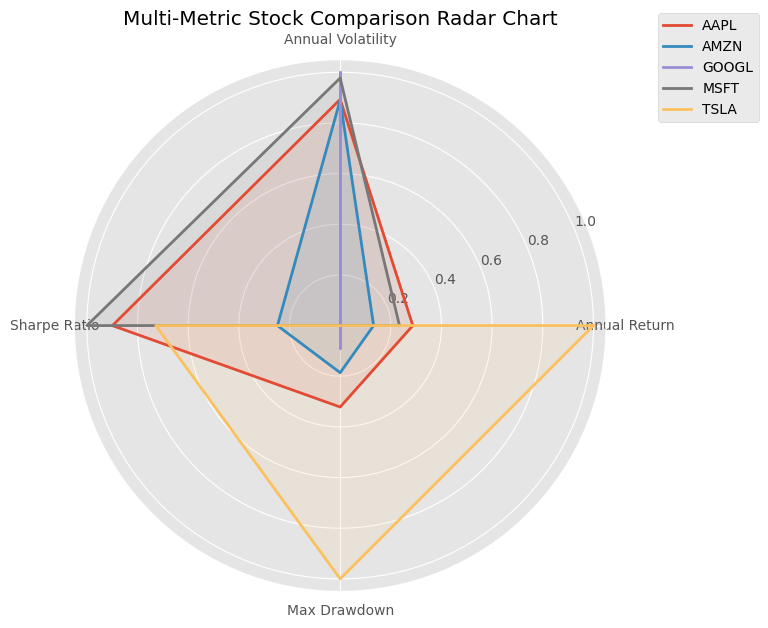

In [49]:
from math import pi

radar_df = summary_df.copy()
radar_df["Max Drawdown"] = max_drawdown

radar_scaled = radar_df.copy()

for col in ["Annual Return", "Sharpe Ratio"]:
    radar_scaled[col] = (radar_df[col] - radar_df[col].min()) / (radar_df[col].max() - radar_df[col].min())

for col in ["Annual Volatility", "Max Drawdown"]:
    radar_scaled[col] = (radar_df[col].max() - radar_df[col]) / (radar_df[col].max() - radar_df[col].min())

categories = ["Annual Return", "Annual Volatility", "Sharpe Ratio", "Max Drawdown"]
N = len(categories)

angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

for stock in radar_scaled.index:
    values = radar_scaled.loc[stock, categories].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=stock)
    ax.fill(angles, values, alpha=0.1)

plt.xticks(angles[:-1], categories)
plt.title("Multi-Metric Stock Comparison Radar Chart")
plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig("outputs/radar_chart.png", dpi=300)
plt.show()

In [ ]:
# 31. Key Findings
This section identifies the top-performing and riskiest stocks based on the calculated metrics.

In [50]:
best_annual_return = summary_df["Annual Return"].idxmax()
highest_volatility = summary_df["Annual Volatility"].idxmax()
best_sharpe = summary_df["Sharpe Ratio"].idxmax()
best_sortino = sortino_summary["Sortino Ratio"].idxmax()
worst_drawdown = max_drawdown.idxmin()
highest_win_ratio = win_loss_summary["Winning Ratio"].idxmax()

print("Highest annual return:", best_annual_return)
print("Highest annual volatility:", highest_volatility)
print("Best Sharpe ratio:", best_sharpe)
print("Best Sortino ratio:", best_sortino)
print("Worst maximum drawdown:", worst_drawdown)
print("Highest winning ratio:", highest_win_ratio)

Highest annual return: TSLA
Highest annual volatility: TSLA
Best Sharpe ratio: MSFT
Best Sortino ratio: MSFT
Worst maximum drawdown: TSLA
Highest winning ratio: MSFT


In [ ]:
# 32. Conclusion

This project provides an extended financial data analysis using WRDS data for five major US technology stocks over the period 2016–2021.

Compared with a simple stock comparison, this notebook adds:

- annualised return and volatility
- Sharpe ratio
- Sortino ratio
- cumulative return analysis
- maximum drawdown analysis
- rolling volatility
- rolling correlation
- monthly return heatmap
- return distribution analysis
- Value at Risk (VaR)
- beta analysis
- winning and losing day analysis
- equal-weight portfolio comparison

These additions improve the analytical depth of the project and make it more suitable as a finance-related data product.

In [51]:
summary_text = f"""
Risk, Return, and Portfolio Analysis of Major US Technology Stocks (2016–2021)

Key findings:
- Highest annual return: {best_annual_return}
- Highest annual volatility: {highest_volatility}
- Best Sharpe ratio: {best_sharpe}
- Best Sortino ratio: {best_sortino}
- Worst maximum drawdown: {worst_drawdown}
- Highest winning ratio: {highest_win_ratio}

This project uses WRDS data to analyse five major US technology stocks over the period 2016–2021.
It compares return, volatility, downside risk, drawdown, correlation, return distribution, Value at Risk, consistency, and equal-weight portfolio performance.
"""

with open("outputs/project_summary.txt", "w", encoding="utf-8") as f:
    f.write(summary_text)

print("Project summary saved.")

Project summary saved.


In [ ]:
# 33. Improvement Part

Based on feedback, I improved the front-end part of the notebook by making the WRDS extraction process more reusable.  
Instead of fixing the WRDS username and stock tickers in separate cells, the improved version wraps the data loading process into a function. This allows users to enter their own WRDS username, choose different stock tickers, and compare them with the overall market.

This section is included as a demonstration of how the notebook can be made more flexible as a data product, while keeping the original full analysis unchanged.

In [10]:
import wrds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("outputs", exist_ok=True)

print("Improvement section: reusable version demonstration")

Improvement section: reusable version demonstration


In [11]:
def load_stock_and_market_data(wrds_username, tickers, start_date="2016-01-01", end_date="2021-12-31"):
    """
    Load selected stock data from WRDS/CRSP and market benchmark data.
    
    Parameters
    ----------
    wrds_username : str
        WRDS username
    tickers : list
        List of stock tickers
    start_date : str
        Start date in YYYY-MM-DD
    end_date : str
        End date in YYYY-MM-DD
    
    Returns
    -------
    stock_df : DataFrame
        Cleaned long-format stock data
    price_df : DataFrame
        Wide-format price table
    returns_df : DataFrame
        Wide-format return table
    market_returns : Series
        Daily market returns
    market_cum_returns : Series
        Cumulative market returns
    """
    
    db_demo = wrds.Connection(wrds_username=wrds_username)

    ticker_list_sql = ",".join([f"'{ticker}'" for ticker in tickers])

    # Extract stock data
    stock_query = f"""
        SELECT a.date, a.permno, b.ticker, b.comnam, a.prc, a.ret, a.vol
        FROM crsp.dsf a
        JOIN crsp.dsenames b
          ON a.permno = b.permno
         AND a.date BETWEEN b.namedt AND b.nameendt
        WHERE b.ticker IN ({ticker_list_sql})
          AND a.date BETWEEN '{start_date}' AND '{end_date}'
        ORDER BY a.date, b.ticker
    """
    stock_df = db_demo.raw_sql(stock_query)

    # Clean stock data
    stock_df["date"] = pd.to_datetime(stock_df["date"])
    stock_df["prc"] = pd.to_numeric(stock_df["prc"], errors="coerce").abs()
    stock_df["ret"] = pd.to_numeric(stock_df["ret"], errors="coerce")
    stock_df["vol"] = pd.to_numeric(stock_df["vol"], errors="coerce")

    stock_df = stock_df.dropna(subset=["date", "ticker", "prc", "ret"])
    stock_df = stock_df.sort_values(["ticker", "date"]).reset_index(drop=True)

    # Create wide tables
    price_df_demo = stock_df.pivot(index="date", columns="ticker", values="prc").sort_index()
    returns_df_demo = stock_df.pivot(index="date", columns="ticker", values="ret").sort_index()

    # Extract market benchmark
    market_query = f"""
        SELECT date, vwretd
        FROM crsp.dsi
        WHERE date BETWEEN '{start_date}' AND '{end_date}'
        ORDER BY date
    """
    market_df = db_demo.raw_sql(market_query)
    market_df["date"] = pd.to_datetime(market_df["date"])
    market_df["vwretd"] = pd.to_numeric(market_df["vwretd"], errors="coerce")
    market_df = market_df.dropna().set_index("date").sort_index()

    market_returns_demo = market_df["vwretd"]
    market_cum_returns_demo = (1 + market_returns_demo).cumprod()

    return stock_df, price_df_demo, returns_df_demo, market_returns_demo, market_cum_returns_demo

In [12]:
# Demonstration inputs for the improved reusable version
demo_wrds_username = "your_wrds_username"   # replace with your WRDS username
demo_tickers = ["AAPL", "MSFT", "AMZN", "GOOGL", "TSLA"]
demo_start_date = "2016-01-01"
demo_end_date = "2021-12-31"

print("Demo WRDS username:", demo_wrds_username)
print("Demo tickers:", demo_tickers)
print("Demo sample period:", demo_start_date, "to", demo_end_date)

Demo WRDS username: your_wrds_username
Demo tickers: ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'TSLA']
Demo sample period: 2016-01-01 to 2021-12-31


In [13]:
stock_df_demo, price_df_demo, returns_df_demo, market_returns_demo, market_cum_returns_demo = load_stock_and_market_data(
    wrds_username=demo_wrds_username,
    tickers=demo_tickers,
    start_date=demo_start_date,
    end_date=demo_end_date
)

print("Reusable demonstration loaded successfully.")
print("Stock data shape:", stock_df_demo.shape)
print("Price table shape:", price_df_demo.shape)
print("Return table shape:", returns_df_demo.shape)

display(stock_df_demo.head())

WRDS recommends setting up a .pgpass file.
pgpass file created at C:\Users\YGspring\AppData\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
Reusable demonstration loaded successfully.
Stock data shape: (7555, 7)
Price table shape: (1511, 5)
Return table shape: (1511, 5)


,date,permno,ticker,comnam,prc,ret,vol
0,2016-01-04,14593,AAPL,APPLE INC,105.35,0.000855,69383612.0
1,2016-01-05,14593,AAPL,APPLE INC,102.71,-0.025059,55791042.0
2,2016-01-06,14593,AAPL,APPLE INC,100.7,-0.01957,68487388.0
3,2016-01-07,14593,AAPL,APPLE INC,96.45,-0.042205,81466204.0
4,2016-01-08,14593,AAPL,APPLE INC,96.96,0.005288,70798746.0


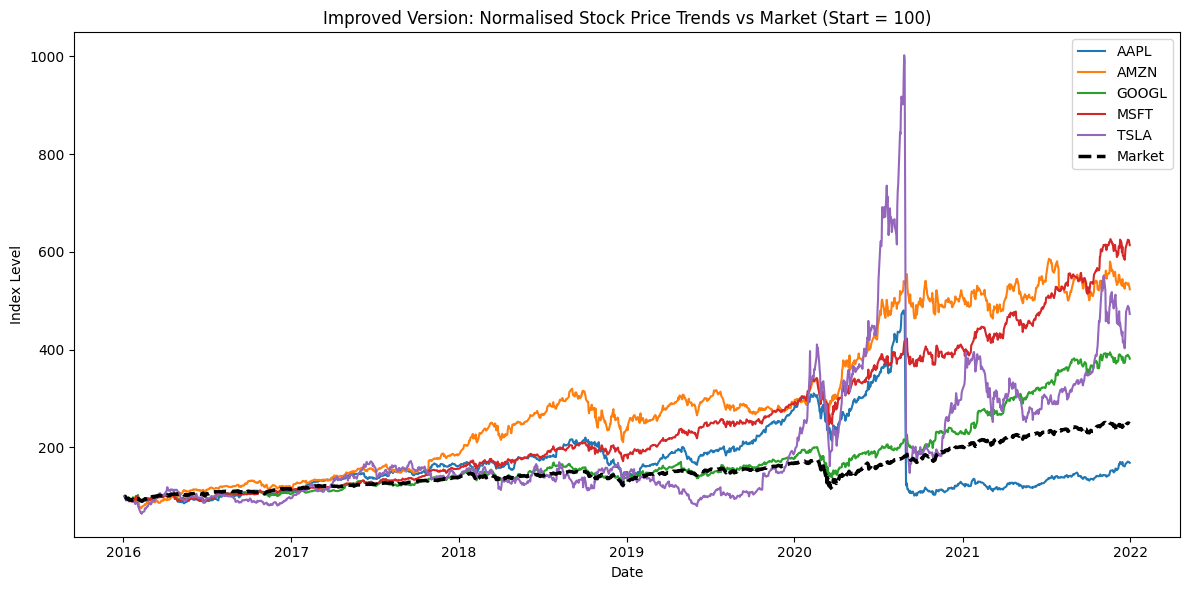

In [14]:
# Normalised stock prices for comparison
normalised_prices_demo = price_df_demo / price_df_demo.iloc[0] * 100

# Convert market cumulative return into index level starting at 100
market_index_demo = market_cum_returns_demo / market_cum_returns_demo.iloc[0] * 100

plt.figure(figsize=(12, 6))

for col in normalised_prices_demo.columns:
    plt.plot(normalised_prices_demo.index, normalised_prices_demo[col], label=col, linewidth=1.5)

plt.plot(market_index_demo.index, market_index_demo, label="Market", color="black", linestyle="--", linewidth=2.5)

plt.title("Improved Version: Normalised Stock Price Trends vs Market (Start = 100)")
plt.xlabel("Date")
plt.ylabel("Index Level")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/improved_price_trends_vs_market.png", dpi=300)
plt.show()

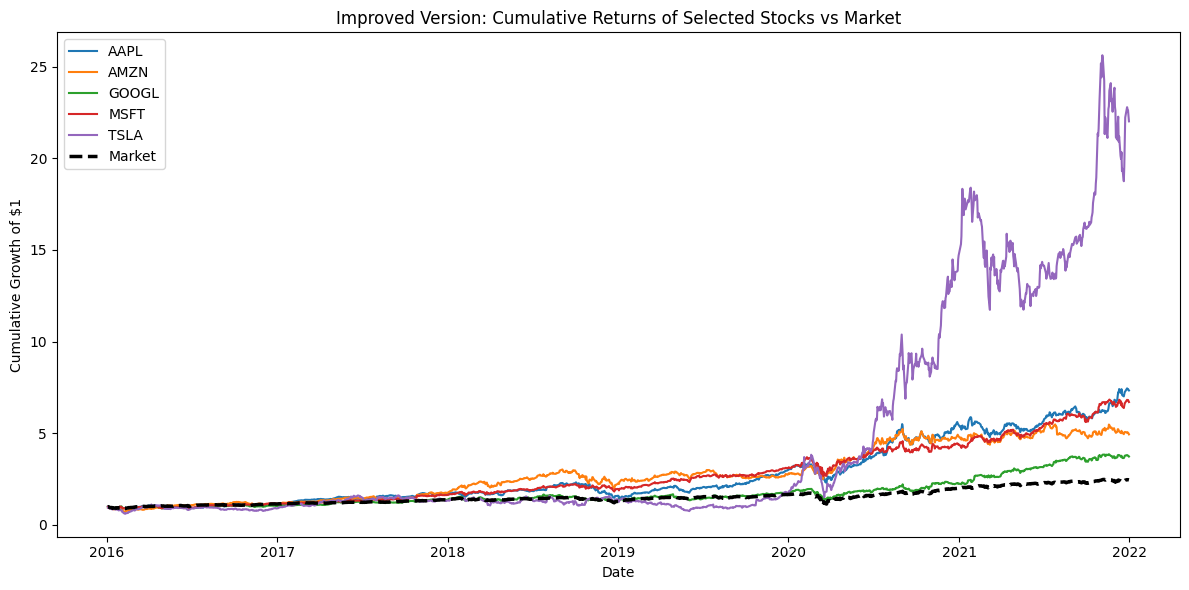

In [15]:
cum_returns_demo = (1 + returns_df_demo).cumprod()

plt.figure(figsize=(12, 6))

for col in cum_returns_demo.columns:
    plt.plot(cum_returns_demo.index, cum_returns_demo[col], label=col, linewidth=1.5)

plt.plot(market_cum_returns_demo.index, market_cum_returns_demo, label="Market", color="black", linestyle="--", linewidth=2.5)

plt.title("Improved Version: Cumulative Returns of Selected Stocks vs Market")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth of $1")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/improved_cumulative_returns_vs_market.png", dpi=300)
plt.show()

In [ ]:
### Explanation of the Improvement

This improved version addresses feedback by making the front section of the notebook more reusable.  
Users can now input:
- a WRDS username
- a list of stock tickers
- a start date and end date

The improved version also adds the **overall market benchmark** to the price trend and cumulative return charts, which gives better context for comparing stock performance.

The main analysis above remains unchanged, while this section demonstrates how the notebook can be enhanced as a more flexible data product.